In [10]:
import numpy as np
import sklearn
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import imageio.v3 as iio
import os
from PIL import Image
import imagehash


# Data loading and Processing

In [11]:
Batch = 32
Random_seed = 42
Image_size = 96

# Modified Data Loading
full_ds = tf.keras.utils.image_dataset_from_directory(
    "Training_Bi/",
    image_size=(Image_size, Image_size),
    batch_size=None,
    shuffle=False, # Set to False to keep sequential order for sharding
    seed=Random_seed
)

# Pick 1 in every 10 frames
# num_shards=10 means split into 10 parts, index=0 takes the first part (0, 10, 20...)
full_ds = full_ds.shard(num_shards=5, index=0)

# Now calculate cardinality and shuffle the reduced dataset
total = tf.data.experimental.cardinality(full_ds).numpy()
train_size = int(0.85 * total)

# Shuffle AFTER sharding so the model sees a random mix of the 1/10th samples
full_ds = full_ds.shuffle(total, seed=Random_seed, reshuffle_each_iteration=False)

train_Bi_raw = full_ds.take(train_size)
val_Bi_raw   = full_ds.skip(train_size)

test_Bi_raw = tf.keras.utils.image_dataset_from_directory(
    "Test/",
    image_size=(Image_size, Image_size),
    batch_size=None,
    shuffle=False
)

print(f"Train: {train_size} | Val: {total - train_size} | Test: {tf.data.experimental.cardinality(test_Bi_raw).numpy()}")

Found 39375 files belonging to 2 classes.
Found 8617 files belonging to 2 classes.
Train: 6693 | Val: 1182 | Test: 8617


In [12]:
def focal_loss(gamma, alpha):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = alpha * tf.pow(1 - p_t, gamma)
        return tf.reduce_mean(focal_weight * bce)
    return loss

def augment(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    # Keep flips and rotations - they are great
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    
    # REDUCE Hue shift - fire color is a key feature!
    image = tf.image.random_hue(image, max_delta=0.02) 
    
    # DEACTIVATE Haze and Blur for now to see if recall improves
    # Or set them to a very low probability (0.1 instead of 0.5)
    return image, label
def augments(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=tf.random.uniform((), 0, 4, dtype=tf.int32))
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.7, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.6)
    image = tf.image.random_hue(image, max_delta=0.02)
    
    # Haze - fixed with tf.cond
    haze_intensity = tf.random.uniform((), 0.05, 0.25)
    haze = tf.ones_like(image) * 0.7
    image = tf.cond(
        tf.random.uniform(()) > 0.5,
        lambda: image * (1 - haze_intensity) + haze * haze_intensity,
        lambda: image
    )

    # Blur - fixed with tf.cond
    def apply_blur(img):
        img = tf.expand_dims(img, 0)
        img = tf.nn.avg_pool2d(img, ksize=3, strides=1, padding='SAME')
        return tf.squeeze(img, 0)

    image = tf.cond(
        tf.random.uniform(()) > 0.6,
        lambda: apply_blur(image),
        lambda: image
    )

    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def compute_class_weights(ds):
    labels = np.array([y.numpy() for _, y in ds])
    counts = np.bincount(labels)
    total = len(labels)
    weights = {i: total / (len(counts) * c) for i, c in enumerate(counts)}
    print(f"Class weights: {weights}")
    return weights

In [13]:
class_weights = compute_class_weights(train_Bi_raw)

train_ds = (
    train_Bi_raw
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    val_Bi_raw
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)
test_ds = (
    test_Bi_raw
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)

Class weights: {0: 0.7851947442515251, 1: 1.376593994241053}


In [14]:
model = keras.models.Sequential([
    keras.layers.Input(shape=(Image_size, Image_size, 3)),
    
    # Block 1: Fast feature extraction
    keras.layers.SeparableConv2D(16, 3, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(),
    
    # Block 2: Deeper features
    keras.layers.SeparableConv2D(32, 3, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(),
   
    # Block 3: Context
    keras.layers.SeparableConv2D(64, 3, activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.GlobalAveragePooling2D(), # Reduces params significantly vs Flatten

    # Output
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-4), # Try a slightly higher LR with BatchNormalization
    loss=focal_loss(gamma=2.0, alpha=0.25), # Use your custom focal loss
    metrics=['accuracy', keras.metrics.Recall(name='recall'), keras.metrics.Precision(name='precision')]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7
    ),
    keras.callbacks.ModelCheckpoint(
        'best_fire_model.keras',
        monitor='val_loss',
        save_best_only=True,
    )
]

history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    class_weight=None,
    callbacks=callbacks
)

Epoch 1/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.8413 - loss: 0.0259 - precision: 0.7690 - recall: 0.8050 - val_accuracy: 0.3723 - val_loss: 0.0461 - val_precision: 0.3723 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.9352 - loss: 0.0144 - precision: 0.9659 - recall: 0.8515 - val_accuracy: 0.8536 - val_loss: 0.0254 - val_precision: 0.7562 - val_recall: 0.8955 - learning_rate: 1.0000e-04
Epoch 3/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.9367 - loss: 0.0119 - precision: 0.9691 - recall: 0.8527 - val_accuracy: 0.9382 - val_loss: 0.0108 - val_precision: 0.9946 - val_recall: 0.8386 - learning_rate: 1.0000e-04
Epoch 4/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.9434 - loss: 0.0105 - precision: 0.9750 - recall: 0.8663 - val_accuracy: 0.9450 - val_loss: 0.0094 - val_precision: 0.9973 - val_recall: 0.8545 - learning_rate: 1.0000e-04
Epoch 5/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 

In [15]:
loss, acc, recall, precision = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test Precision: {precision:.4f}")

# Get probabilities
y_pred_prob = model.predict(test_ds)

# 2. Confusion matrix
true_labels = np.concatenate([y.numpy() for _, y in test_ds])

pred_classes = (y_pred_prob > 0.5).astype(int).flatten()
cm = confusion_matrix(true_labels, pred_classes)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(true_labels, pred_classes, 
      target_names=['No_Fire', 'Fire'], 
      zero_division=0))  # ← add this

# Then after predicting, run the threshold sweep FIRST:
for t in np.arange(0.10, 0.90, 0.05):
    preds = (y_pred_prob > t).astype(int).flatten()
    report = classification_report(true_labels, preds, 
                                   target_names=['No_Fire','Fire'],
                                   output_dict=True, zero_division=0)
    print(f"t={t:.2f} | No_Fire F1: {report['No_Fire']['f1-score']:.2f} | Fire F1: {report['Fire']['f1-score']:.2f} | macro F1: {report['macro avg']['f1-score']:.2f}")

270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5914 - loss: 0.0754 - precision: 0.4932 - recall: 0.4244
Test Loss: 0.0754
Test Accuracy: 0.5914
Test Recall: 0.4244
Test Precision: 0.4932
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Confusion Matrix:
[[3619 1518]
 [2003 1477]]

Classification Report:
              precision    recall  f1-score   support

     No_Fire       0.64      0.70      0.67      5137
        Fire       0.49      0.42      0.46      3480

    accuracy                           0.59      8617
   macro avg       0.57      0.56      0.56      8617
weighted avg       0.58      0.59      0.59      8617

t=0.10 | No_Fire F1: 0.11 | Fire F1: 0.59 | macro F1: 0.35
t=0.15 | No_Fire F1: 0.24 | Fire F1: 0.59 | macro F1: 0.42
t=0.20 | No_Fire F1: 0.37 | Fire F1: 0.55 | macro F1: 0.46
t=0.25 | No_Fire F1: 0.47 | Fire F1: 0.53 | macro F1: 0.50
t=0.30 | No_Fire F1: 0.52 | Fire F1: 0.50 | macro F1: 0.51
t=0.35 | No_Fire F1: 0.57 | Fire F1: 0.49 | macro F1: 0.53
t=0.40 | No_Fi

Train — Fire: 4262 | No_Fire: 2431
Test  — Fire: 5137 | No_Fire: 3480


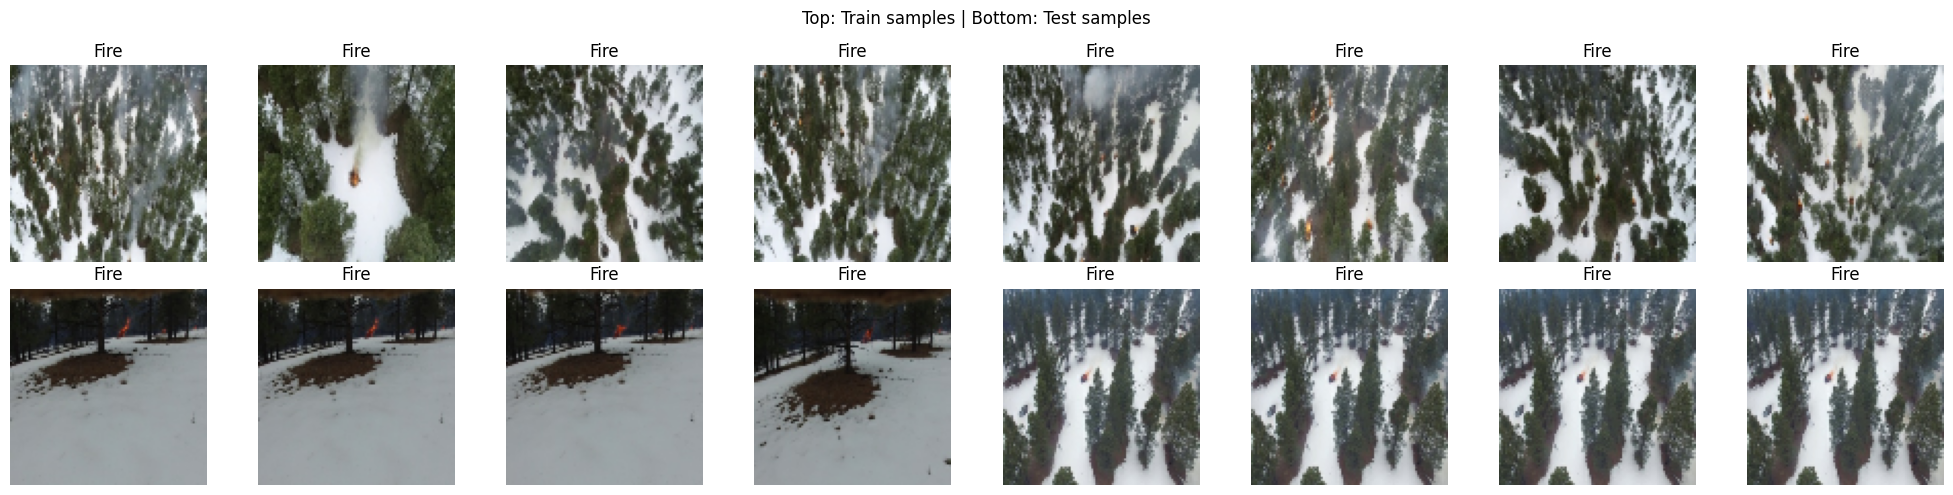

In [16]:
# 1. Check class balance in test vs train
test_labels = np.array([y.numpy() for _, y in test_Bi_raw])
train_labels = np.array([y.numpy() for _, y in train_Bi_raw])

print("Train — Fire:", (train_labels==0).sum(), "| No_Fire:", (train_labels==1).sum())
print("Test  — Fire:", (test_labels==0).sum(),  "| No_Fire:", (test_labels==1).sum())

# 2. Visually inspect some test images vs train images
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle("Top: Train samples | Bottom: Test samples")

for i, (img, label) in enumerate(train_Bi_raw.take(8)):
    axes[0, i].imshow(img.numpy().astype("uint8"))
    axes[0, i].set_title(f"{'Fire' if label==0 else 'No_Fire'}")
    axes[0, i].axis('off')

for i, (img, label) in enumerate(test_Bi_raw.take(8)):
    axes[1, i].imshow(img.numpy().astype("uint8"))
    axes[1, i].set_title(f"{'Fire' if label==0 else 'No_Fire'}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [17]:
import os
print("Test subfolders:", os.listdir("Test/"))
print("Train subfolders:", os.listdir("Training_Bi_Deduped/"))

# Count files per class
for folder in os.listdir("Test/"):
    count = len(os.listdir(f"Test/{folder}"))
    print(f"  Test/{folder}: {count} images")

Test subfolders: ['Fire', 'No_Fire']
Train subfolders: ['Fire', 'No_Fire']
  Test/Fire: 5137 images
  Test/No_Fire: 3480 images


270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


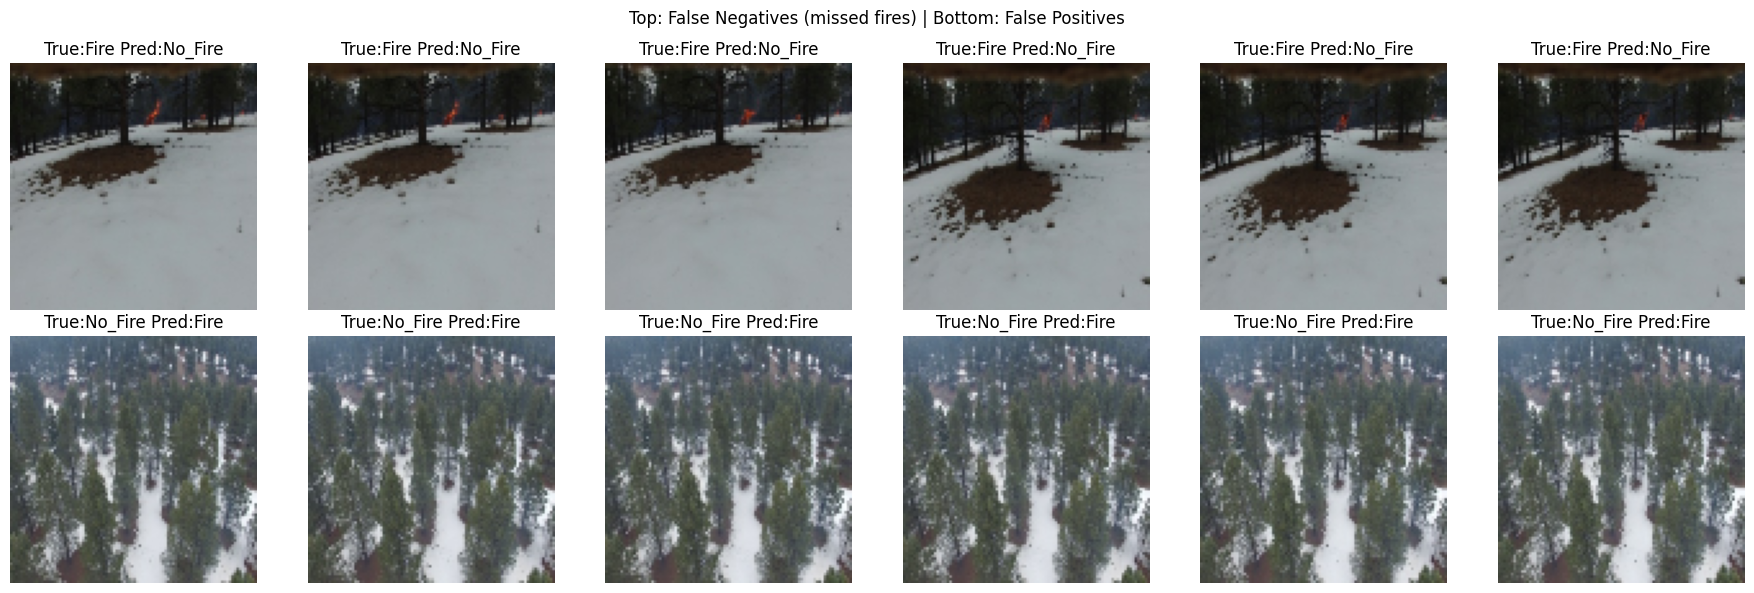

In [18]:
y_pred_prob = model.predict(test_ds)
pred_classes = (y_pred_prob > 0.5).astype(int).flatten()
true_labels = np.concatenate([y.numpy() for _, y in test_ds])

# Find false negatives (predicted No_Fire but actually Fire)
fn_indices = np.where((pred_classes == 1) & (true_labels == 0))[0]
# Find false positives (predicted Fire but actually No_Fire)  
fp_indices = np.where((pred_classes == 0) & (true_labels == 1))[0]

# Get all test images
all_images = np.concatenate([x.numpy() for x, _ in test_ds])

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle("Top: False Negatives (missed fires) | Bottom: False Positives")
for i, idx in enumerate(fn_indices[:6]):
    axes[0,i].imshow(all_images[idx])
    axes[0,i].set_title(f"True:Fire Pred:No_Fire")
    axes[0,i].axis('off')
for i, idx in enumerate(fp_indices[:6]):
    axes[1,i].imshow(all_images[idx])
    axes[1,i].set_title(f"True:No_Fire Pred:Fire")
    axes[1,i].axis('off')
plt.tight_layout()
plt.show()